# Story 4: Tồn kho và Returns: Bao nhiêu tiền đang bị để lại trên bàn?

## 4a. Stockout x Demand Peak
- tính avg_stockout_days mỗi tháng theo category
- monthly_revenue_index (đã tính ở Chart 1b)
- est_lost_revenue_monthly = stockout_days × avg_daily_revenue_tháng_đó
- Dual-axis: bar chart est_lost_revenue  + line chart revenue_index

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker
import numpy as np

print("Đang đọc dữ liệu từ thư mục ../data/raw/ ...")

orders = pd.read_csv('../data/raw/orders.csv')
order_items = pd.read_csv('../data/raw/order_items.csv')
products = pd.read_csv('../data/raw/products.csv')
inventory = pd.read_csv('../data/raw/inventory.csv')

print("Đọc thành công! Check thử vài dòng data orders:")
display(orders.head(3))

Đang đọc dữ liệu từ thư mục ../data/raw/ ...


C:\Users\ms24\AppData\Local\Temp\ipykernel_4328\3130792852.py:10: DtypeWarning: Columns (0: promo_id_2) have mixed types. Specify dtype option on import or set low_memory=False.
  order_items = pd.read_csv('../data/raw/order_items.csv')


Đọc thành công! Check thử vài dòng data orders:


,order_id,order_date,customer_id,zip,order_status,payment_method,device_type,order_source
0,1,2012-07-04,58578,1109,delivered,credit_card,desktop,paid_search
1,2,2012-07-04,58621,1330,returned,cod,mobile,paid_search
2,3,2012-07-04,58811,1473,delivered,credit_card,desktop,direct


In [3]:
print("Đang xử lý và gộp dữ liệu...")

# 1. Tính doanh thu từ các đơn hàng
df_sales = orders.merge(order_items, on='order_id').merge(products, on='product_id')
df_sales['order_date'] = pd.to_datetime(df_sales['order_date'])
df_sales['year'] = df_sales['order_date'].dt.year
df_sales['month'] = df_sales['order_date'].dt.month
df_sales['revenue'] = df_sales['quantity'] * df_sales['unit_price']

# 2. Group doanh thu theo Năm-Tháng và Category
monthly_revenue = df_sales.groupby(['year', 'month', 'category'])['revenue'].sum().reset_index()

# Tính số ngày trong tháng để suy ra doanh thu trung bình ngày
monthly_revenue['date'] = pd.to_datetime(monthly_revenue[['year', 'month']].assign(DAY=1))
monthly_revenue['days_in_month'] = monthly_revenue['date'].dt.daysinmonth
monthly_revenue['avg_daily_revenue'] = monthly_revenue['revenue'] / monthly_revenue['days_in_month']

# 3. Tính monthly_revenue_index 
cat_mean_revenue = monthly_revenue.groupby('category')['revenue'].transform('mean')
monthly_revenue['monthly_revenue_index'] = (monthly_revenue['revenue'] / cat_mean_revenue) * 100

# 4. Tính số ngày stockout trung bình từ bảng Inventory
monthly_inv = inventory.groupby(['year', 'month', 'category'])['stockout_days'].mean().reset_index()
monthly_inv.rename(columns={'stockout_days': 'avg_stockout_days'}, inplace=True)

# 5. Merge Dữ liệu doanh thu và tồn kho để tính Est Lost Revenue
df_chart = pd.merge(monthly_revenue, monthly_inv, on=['year', 'month', 'category'], how='inner')
df_chart['est_lost_revenue'] = df_chart['avg_stockout_days'] * df_chart['avg_daily_revenue']
df_chart['month_year_label'] = df_chart['date'].dt.strftime('%m-%Y')

print("Xử lý xong! Cấu trúc dữ liệu cuối cùng để vẽ chart:")
display(df_chart.head(3))

Đang xử lý và gộp dữ liệu...
Xử lý xong! Cấu trúc dữ liệu cuối cùng để vẽ chart:


,year,month,category,revenue,date,days_in_month,avg_daily_revenue,monthly_revenue_index,avg_stockout_days,est_lost_revenue,month_year_label
0,2012,7,Casual,2383588.69,2012-07-01,31,76889.957742,65.197705,1.187500,91306.824819,07-2012
1,2012,7,GenZ,2251165.29,2012-07-01,31,72618.235161,82.551680,1.266667,91983.097871,07-2012
2,2012,7,Outdoor,17723691.11,2012-07-01,31,571731.971290,89.510622,0.944828,540188.138392,07-2012


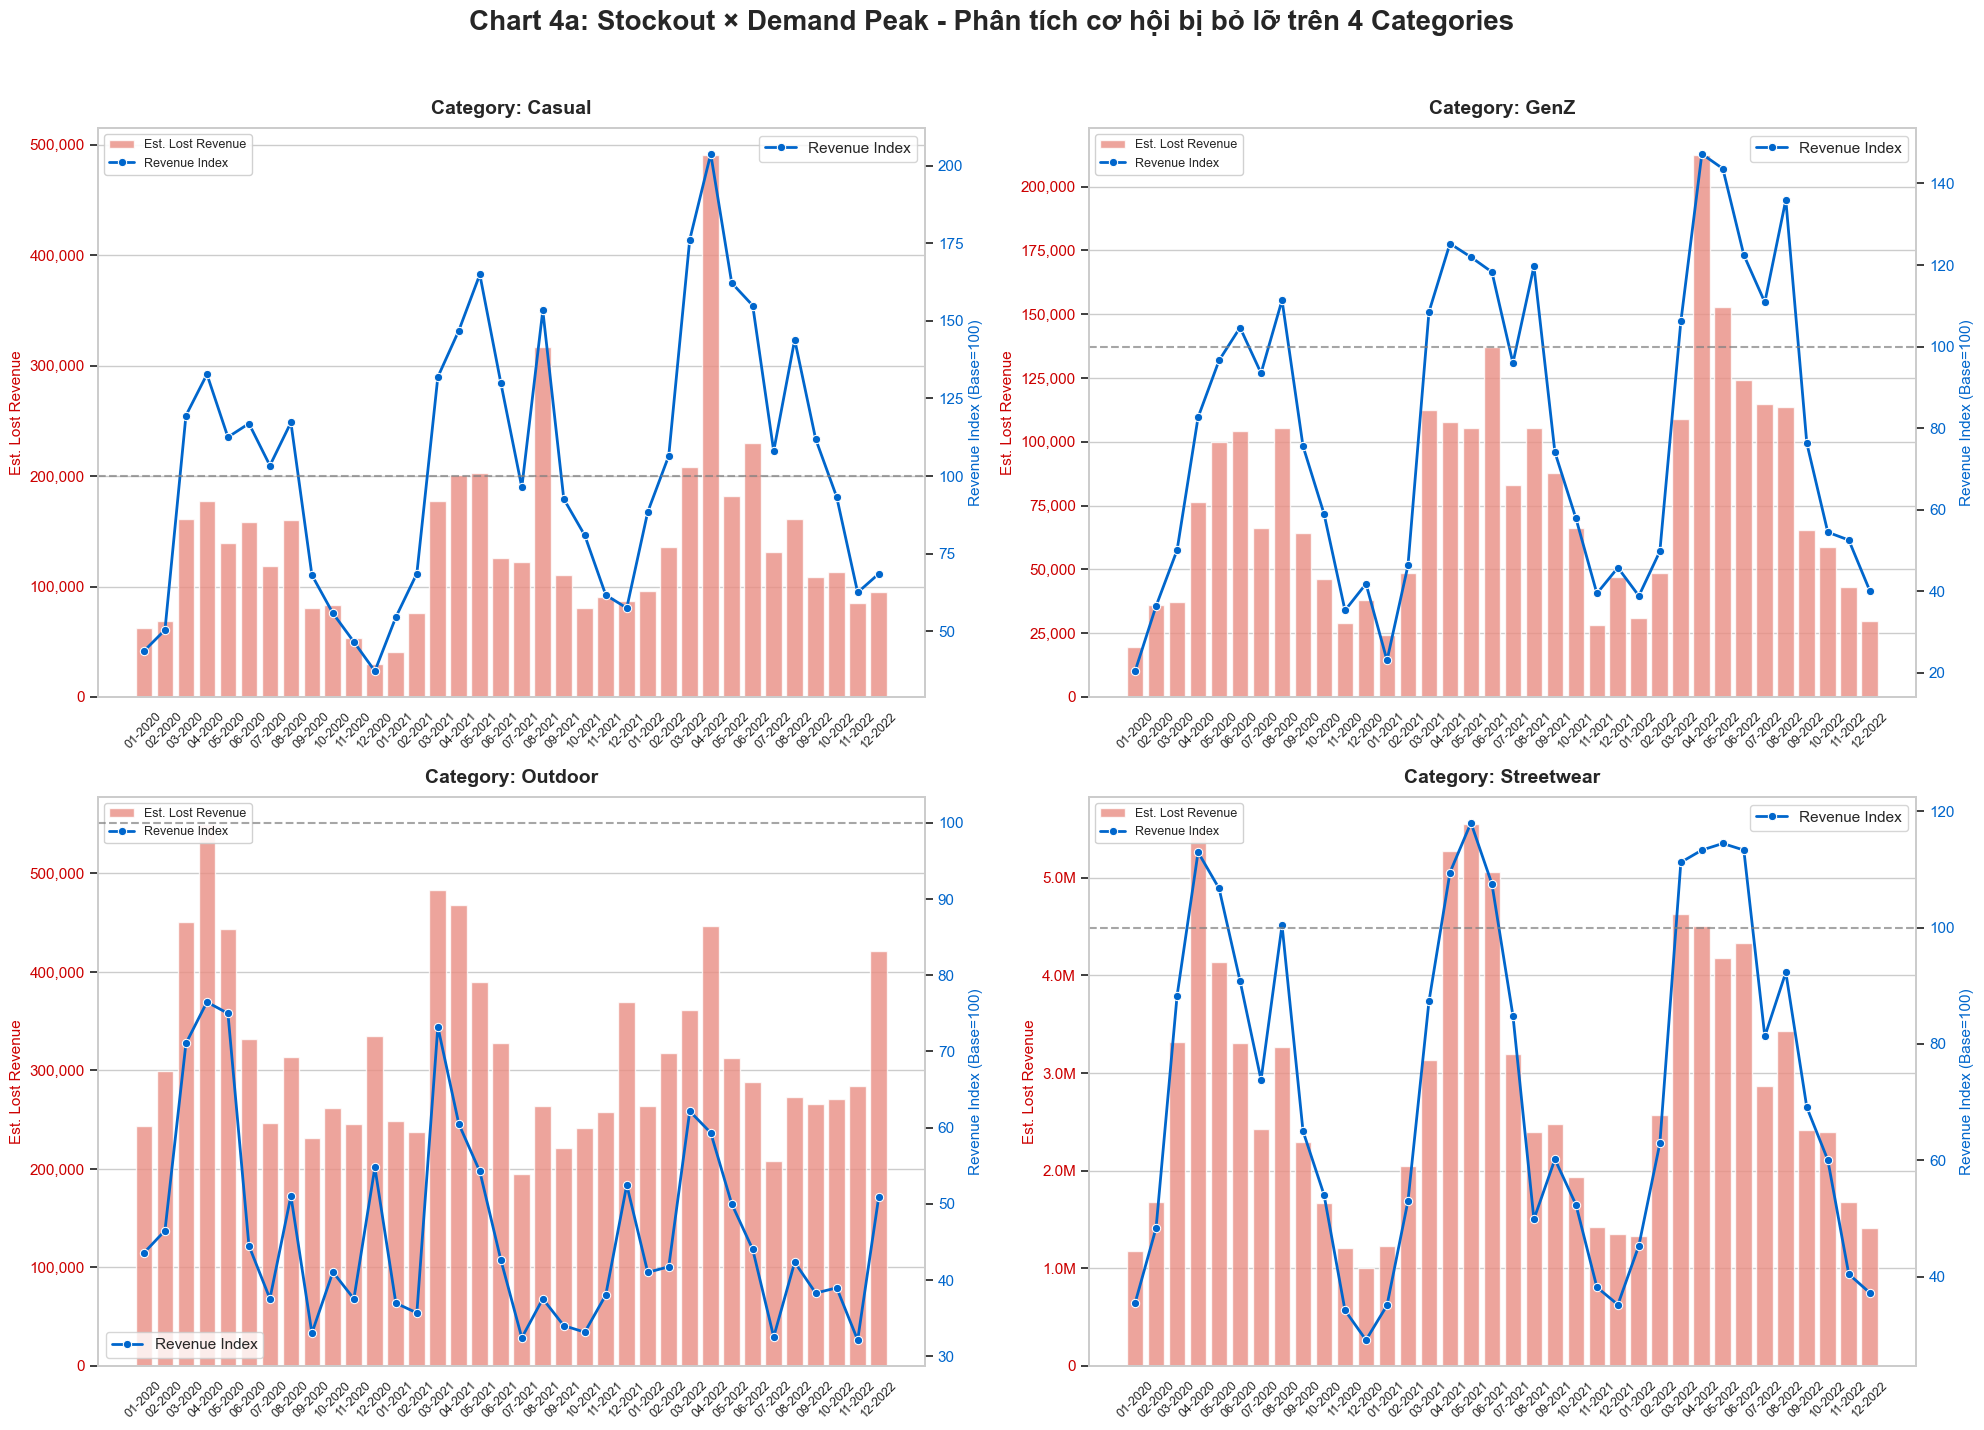

In [4]:
def plot_all_4_categories(df):
    sns.set_theme(style="whitegrid")
    # Lấy danh sách tối đa 4 categories
    categories = df['category'].unique()[:4]
    
    if len(categories) == 0:
        print("❌ Không có category nào trong dữ liệu!")
        return

    # Tạo bảng lưới 2x2 (2 hàng, 2 cột), kích thước lớn để không bị ép chữ
    fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(20, 14))
    axes = axes.flatten() # Trải phẳng mảng axes để dễ vòng lặp
    
    # Format số tiền (rút gọn K, M)
    formatter = ticker.FuncFormatter(lambda x, pos: f'{x/1000000:,.1f}M' if x >= 1000000 else f'{x:,.0f}')

    for i, cat in enumerate(categories):
        ax1 = axes[i]
        
        # Lọc data theo category và lấy 24 tháng gần nhất
        plot_data = df[df['category'] == cat].sort_values('date').tail(36)
        
        if plot_data.empty:
            ax1.set_visible(False)
            continue

        # --- Trục 1 (Bên trái) - Bar Chart ---
        sns.barplot(
            data=plot_data, x='month_year_label', y='est_lost_revenue', 
            color='salmon', alpha=0.8, ax=ax1, label='Est. Lost Revenue'
        )
        
        ax1.set_xlabel('') # Ẩn chữ "Tháng" cho đỡ rối
        ax1.set_ylabel('Est. Lost Revenue', color='#cc0000', fontsize=11)
        ax1.tick_params(axis='y', labelcolor='#cc0000')
        ax1.tick_params(axis='x', rotation=45, labelsize=9)
        ax1.yaxis.set_major_formatter(formatter)

        # --- Trục 2 (Bên phải) - Line Chart ---
        ax2 = ax1.twinx()  
        
        sns.lineplot(
            data=plot_data, x='month_year_label', y='monthly_revenue_index', 
            color='#0066cc', marker='o', linewidth=2, ax=ax2,
            label='Revenue Index', sort=False 
        )
        
        ax2.set_ylabel('Revenue Index (Base=100)', color='#0066cc', fontsize=11)
        ax2.tick_params(axis='y', labelcolor='#0066cc')
        ax2.axhline(y=100, color='gray', linestyle='--', alpha=0.7)

        # --- Decorate từng biểu đồ con ---
        ax1.set_title(f'Category: {cat}', fontsize=14, fontweight='bold', pad=10)
        
        # Gộp legend của 2 trục lại vào 1 chỗ cho gọn
        lines1, labels1 = ax1.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=9, framealpha=0.9)
        ax2.grid(False)

    # Nếu số lượng category ít hơn 4, ẩn các ô bị dư
    for j in range(i + 1, 4):
        axes[j].set_visible(False)

    # Tiêu đề tổng cho toàn bộ Figure
    fig.suptitle('Chart 4a: Stockout × Demand Peak - Phân tích cơ hội bị bỏ lỡ trên 4 Categories', 
                 fontsize=20, fontweight='bold', y=1.02)

    plt.tight_layout()
    plt.show()

plot_all_4_categories(df_chart)

## 4.b. Return Rate × Product Margin: Ma trận quyết định danh mục

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker
import numpy as np

print("Đang đọc dữ liệu từ ../data/raw/ ...")
products = pd.read_csv('../data/raw/products.csv')
order_items = pd.read_csv('../data/raw/order_items.csv')
returns = pd.read_csv('../data/raw/returns.csv')

print("Đang tổng hợp Sales và Returns theo từng Product...")

# 1. Tính tổng bán ra (Sales)
order_items['item_revenue'] = order_items['quantity'] * order_items['unit_price']
sales_agg = order_items.groupby('product_id').agg(
    units_sold=('quantity', 'sum'),
    revenue=('item_revenue', 'sum')
).reset_index()

# 2. Tính tổng trả về (Returns)
returns_agg = returns.groupby('product_id').agg(
    return_quantity=('return_quantity', 'sum'),
    refund_amount=('refund_amount', 'sum')
).reset_index()

# 3. Gộp tất cả vào bảng Products
df_matrix = products.merge(sales_agg, on='product_id', how='left')
df_matrix = df_matrix.merge(returns_agg, on='product_id', how='left')

# Lấp đầy các sản phẩm không có người mua hoặc không bị trả hàng bằng 0
df_matrix.fillna({'return_quantity': 0, 'refund_amount': 0, 'units_sold': 0, 'revenue': 0}, inplace=True)

# Lọc bỏ các sản phẩm chưa từng được bán ra (tránh lỗi chia cho 0)
df_matrix = df_matrix[df_matrix['units_sold'] > 0].copy()

display(df_matrix.head(3))

Đang đọc dữ liệu từ ../data/raw/ ...
Đang tổng hợp Sales và Returns theo từng Product...


C:\Users\ms24\AppData\Local\Temp\ipykernel_16680\2217251851.py:9: DtypeWarning: Columns (0: promo_id_2) have mixed types. Specify dtype option on import or set low_memory=False.
  order_items = pd.read_csv('../data/raw/order_items.csv')


,product_id,product_name,category,segment,size,color,price,cogs,units_sold,revenue,return_quantity,refund_amount
0,536,SaigonFlex UC-01,Streetwear,Everyday,S,green,11059.650000,9704.842875,108.0,1162761.68,10.0,104934.10
1,537,SaigonFlex UC-02,Streetwear,Everyday,M,silver,9523.076013,5393.870254,367.0,3296751.16,10.0,88104.72
2,538,SaigonFlex UC-03,Streetwear,Everyday,L,pink,15951.633158,11371.919278,82.0,1237815.89,3.0,45950.75


In [20]:
print("Đang tính toán các chỉ số Margin và Return...")

# Tính Return Rate
df_matrix['return_rate'] = df_matrix['return_quantity'] / df_matrix['units_sold']

# Tính Margin Rate (Biên lợi nhuận gộp)
df_matrix['margin_rate'] = (df_matrix['price'] - df_matrix['cogs']) / df_matrix['price']

# Tính Net Margin (Biên lợi nhuận ròng sau khi trừ tiền hoàn trả)
# Tránh lỗi chia cho 0 nếu revenue = 0
df_matrix['net_margin'] = df_matrix.apply(
    lambda row: row['margin_rate'] - (row['return_rate'] * row['refund_amount'] / row['revenue']) 
    if row['revenue'] > 0 else 0, 
    axis=1
)

print("Cấu trúc dữ liệu sẵn sàng để vẽ Matrix:")
display(df_matrix[['product_id', 'category', 'margin_rate', 'return_rate', 'revenue', 'net_margin']].head(3))

Đang tính toán các chỉ số Margin và Return...
Cấu trúc dữ liệu sẵn sàng để vẽ Matrix:


,product_id,category,margin_rate,return_rate,revenue,net_margin
0,536,Streetwear,0.1225,0.092593,1162761.68,0.114144
1,537,Streetwear,0.4336,0.027248,3296751.16,0.432872
2,538,Streetwear,0.2871,0.036585,1237815.89,0.285742


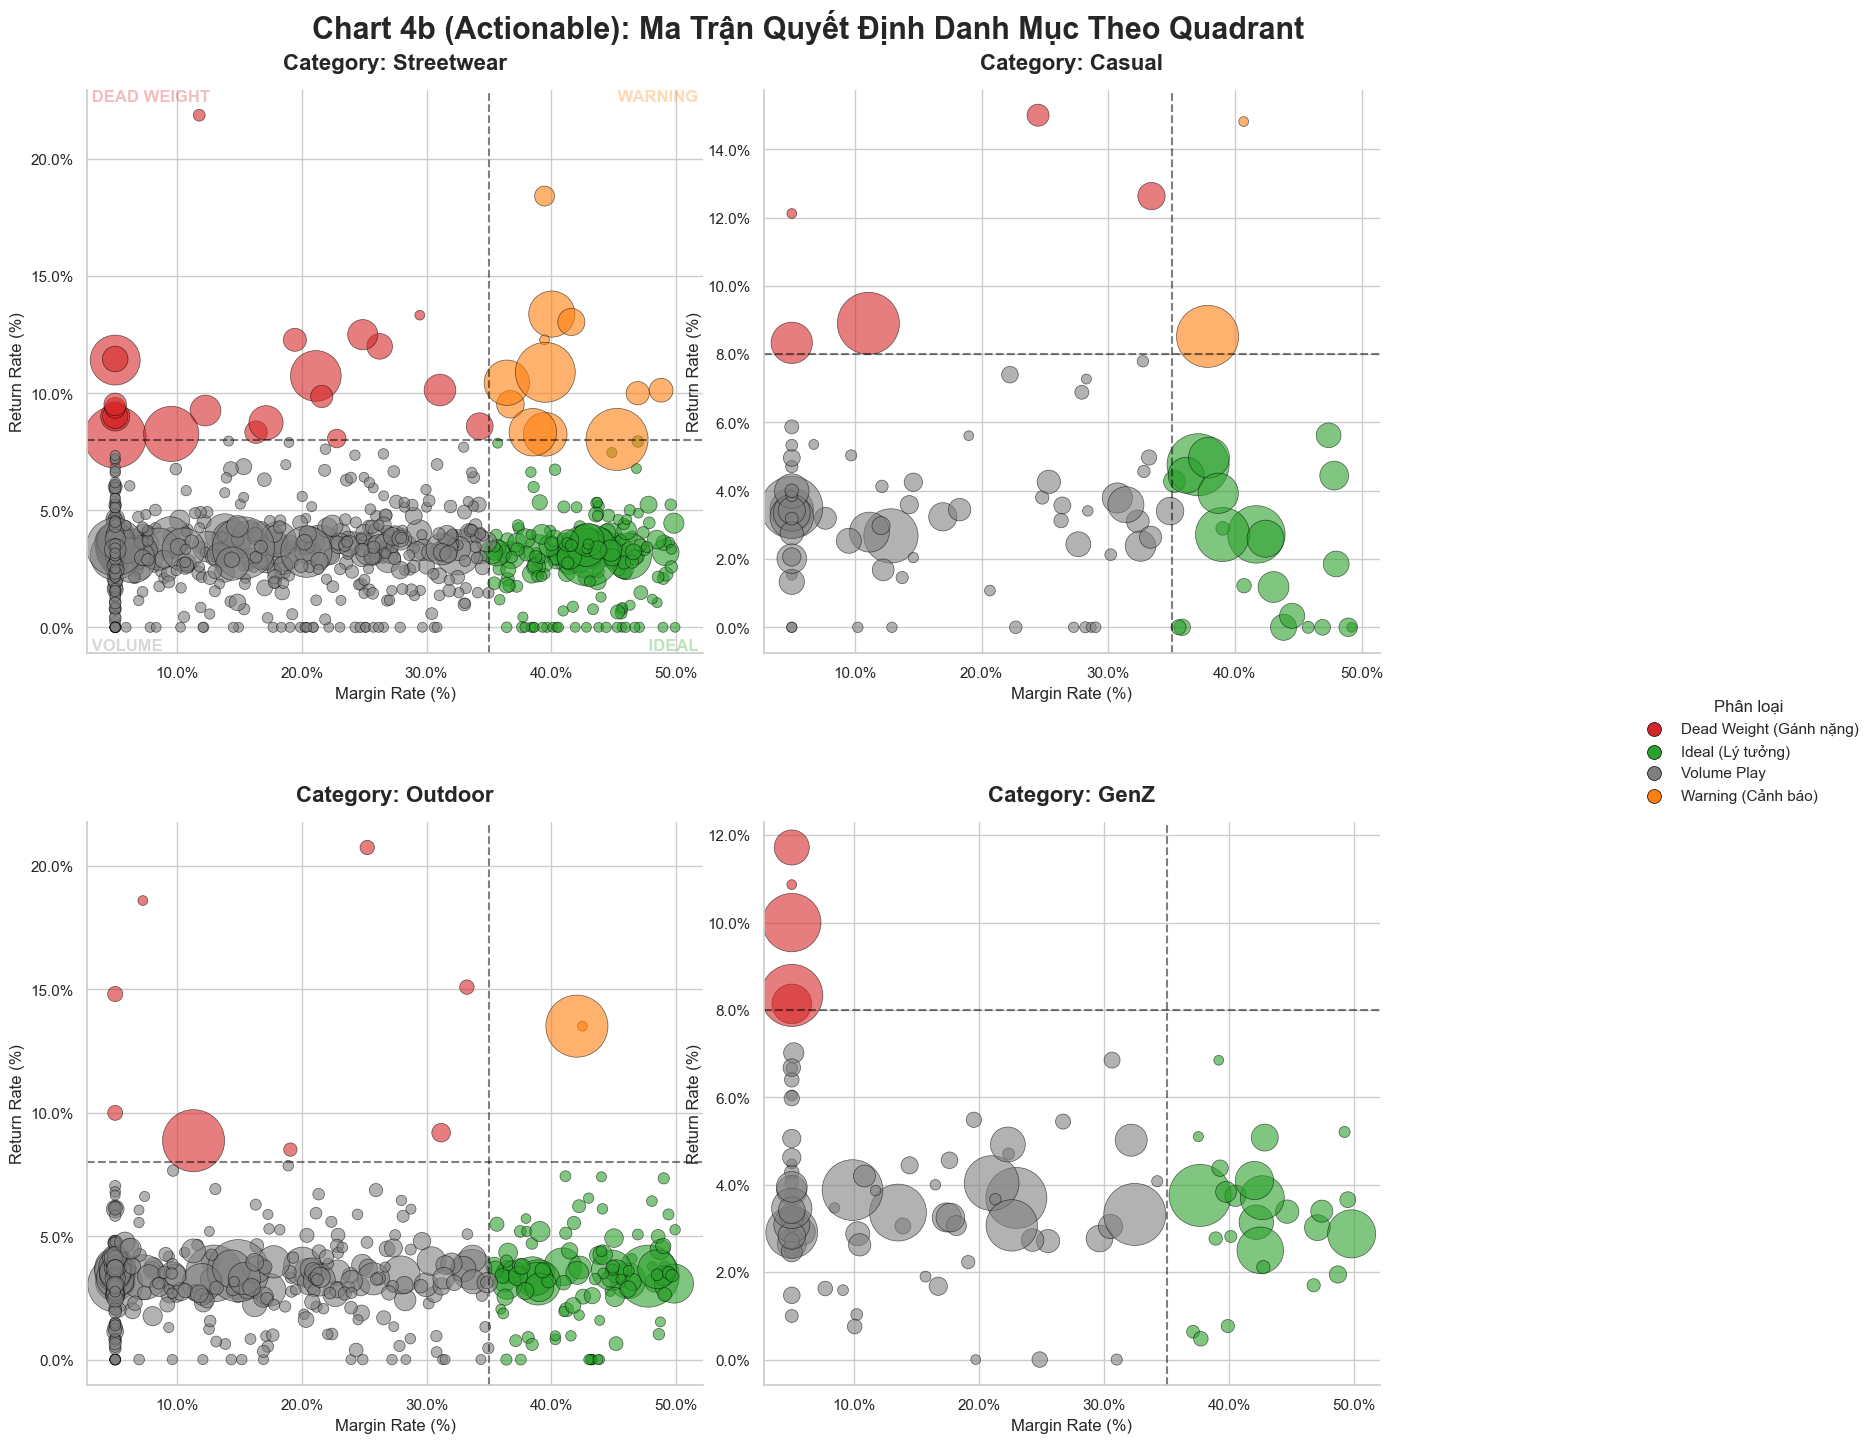

In [ ]:
import numpy as np
import matplotlib.ticker as ticker
import seaborn as sns
import matplotlib.pyplot as plt

def plot_portfolio_matrix_v4_colored(df):
    sns.set_theme(style="whitegrid")
    
    # 1. Lọc nhiễu
    df_filtered = df[df['units_sold'] >= 30].copy()
    
    # 2. Ngưỡng KPIs
    margin_threshold = 0.35  
    return_threshold = 0.08  

    # 3. AUTO-TAGGING: Phân loại sản phẩm vào 4 nhóm dựa trên framework
    conditions = [
        (df_filtered['margin_rate'] >= margin_threshold) & (df_filtered['return_rate'] < return_threshold),
        (df_filtered['margin_rate'] >= margin_threshold) & (df_filtered['return_rate'] >= return_threshold),
        (df_filtered['margin_rate'] < margin_threshold) & (df_filtered['return_rate'] < return_threshold),
        (df_filtered['margin_rate'] < margin_threshold) & (df_filtered['return_rate'] >= return_threshold)
    ]
    choices = ['Ideal (Lý tưởng)', 'Warning (Cảnh báo)', 'Volume Play', 'Dead Weight (Gánh nặng)']
    
    # Tạo cột mới 'quadrant'
    df_filtered['quadrant'] = np.select(conditions, choices, default='Khác')

    # 4. BẢNG MÀU CHỈ ĐỊNH (Custom Palette)
    # Xanh cho ngon, Đỏ cho lỗ, Vàng cảnh báo, Xám kệ nó
    quadrant_palette = {
        'Ideal (Lý tưởng)': '#2ca02c',       # Xanh lá
        'Warning (Cảnh báo)': '#ff7f0e',     # Cam/Vàng
        'Volume Play': '#7f7f7f',            # Xám
        'Dead Weight (Gánh nặng)': '#d62728' # Đỏ
    }

    # 5. VẼ FACETGRID
    g = sns.FacetGrid(
        df_filtered, 
        col="category",      
        col_wrap=2,          
        height=7,            
        aspect=1,            
        sharex=False,         
        sharey=False,
        hue="quadrant",      
        palette=quadrant_palette
    )

    # 6. MAPPING DỮ LIỆU
    g.map_dataframe(
        sns.scatterplot, 
        x='margin_rate', 
        y='return_rate', 
        size='revenue', 
        sizes=(50, 2000), 
        alpha=0.6,          
        edgecolor='black',
        linewidth=0.5, 
        legend=False
    )

    # 7. VẼ
    for cat_name, ax in g.axes_dict.items():
        # Vẽ 2 vạch KPIs
        ax.axvline(x=margin_threshold, color='black', linestyle='--', alpha=0.5, linewidth=1.5)
        ax.axhline(y=return_threshold, color='black', linestyle='--', alpha=0.5, linewidth=1.5)

        ax.xaxis.set_major_formatter(ticker.PercentFormatter(1.0))
        ax.yaxis.set_major_formatter(ticker.PercentFormatter(1.0))
        
        ax.set_title(f'Category: {cat_name}', fontsize=16, fontweight='bold', pad=15)
        ax.set_xlabel('Margin Rate (%)', fontsize=12)
        ax.set_ylabel('Return Rate (%)', fontsize=12)
        
        # Thêm note chìm vào 4 góc
        x_min, x_max = ax.get_xlim()
        y_min, y_max = ax.get_ylim()
        
        if cat_name == list(g.axes_dict.keys())[0]:
             ax.text(x_max, y_min, ' IDEAL ', fontsize=12, color='#2ca02c', fontweight='bold', ha='right', va='bottom', alpha=0.3)
             ax.text(x_max, y_max, ' WARNING ', fontsize=12, color='#ff7f0e', fontweight='bold', ha='right', va='top', alpha=0.3)
             ax.text(x_min, y_min, ' VOLUME ', fontsize=12, color='#7f7f7f', fontweight='bold', ha='left', va='bottom', alpha=0.3)
             ax.text(x_min, y_max, ' DEAD WEIGHT ', fontsize=12, color='#d62728', fontweight='bold', ha='left', va='top', alpha=0.3)

    g.fig.suptitle('Chart 4b (Actionable): Ma Trận Quyết Định Danh Mục Theo Quadrant', 
                   fontsize=22, fontweight='bold', y=1.03)
    
    g.add_legend(title="Phân loại", loc='center left', bbox_to_anchor=(1.0, 0.5))

    for lh in g._legend.legend_handles:
        lh.set_alpha(1)      
        lh.set_sizes([100])  

    plt.subplots_adjust(right=0.85, hspace=0.3)
    
    plt.show()

plot_portfolio_matrix_v4_colored(df_matrix)